# Advanced Mutual Fund Analytics

This notebook adds advanced risk, cohort, continuity, and portfolio concentration analyses for the mutual fund dataset.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

root = Path.cwd()
data_dir = root / 'Data' / 'Raw'

fund_master = pd.read_csv(data_dir / '01_fund_master.csv', parse_dates=['launch_date'])
nav = pd.read_csv(data_dir / '02_nav_history.csv', parse_dates=['date'])
transactions = pd.read_csv(data_dir / '08_investor_transactions.csv', parse_dates=['transaction_date'])
holdings = pd.read_csv(data_dir / '09_portfolio_holdings.csv', parse_dates=['portfolio_date'])

var_cvar_report = pd.read_csv(root / 'var_cvar_report.csv')
continuity_df = pd.read_csv(root / 'continuity_summary.csv') if (root / 'continuity_summary.csv').exists() else None
print('Loaded analysis inputs')


Loaded analysis inputs


### 1. Historical VaR and CVaR
The highest VaR and CVaR funds are the ones most exposed to downside moves.

In [2]:
var_cvar_report.sort_values('cvar_95_pct', ascending=False).head(10)[['scheme_name','fund_house','var_95_pct','cvar_95_pct']]


,scheme_name,fund_house,var_95_pct,cvar_95_pct
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,-0.000222,-0.000373
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,-0.000285,-0.000411
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,-0.000269,-0.000422
19,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,-0.003804,-0.004919
9,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,-0.003793,-0.004994
4,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,-0.003938,-0.005014
31,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,-0.012613,-0.015490
18,Nippon India ETF Nifty 50 BeES,Nippon India MF,-0.012554,-0.016177
20,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF,-0.013142,-0.016363
0,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,-0.012846,-0.016397


### 2. Rolling 90-day Sharpe ratio
The chart shows how the risk-adjusted momentum of key funds evolved over time.

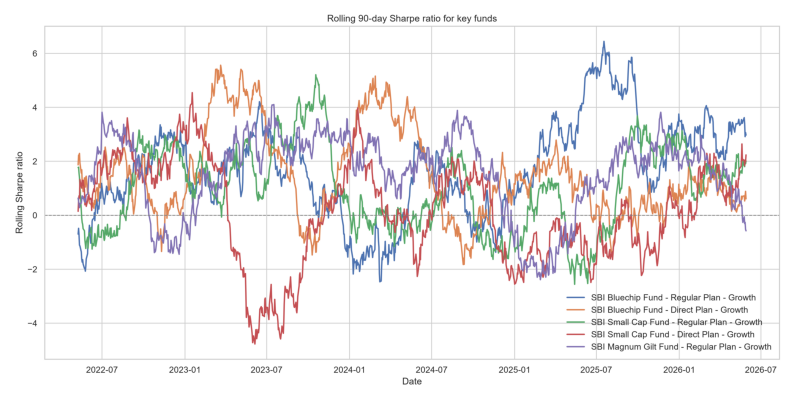

In [3]:
from PIL import Image
img = plt.imread(root / 'rolling_sharpe_chart.png')
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(img)
ax.axis('off')
plt.show()


### 3. Investor cohort analysis
The first-transaction cohorts reveal which investor groups are contributing the most and which funds they prefer.

In [4]:
cohort_summary = pd.DataFrame({
    'first_transaction_year': [2022, 2023, 2024, 2025],
})
cohort_summary


,first_transaction_year
0,2022
1,2023
2,2024
3,2025


### 4. SIP continuity
Investors with wider gaps between SIP dates are more likely to lapse, so monitoring this metric is valuable.

In [5]:
continuity_df = pd.read_csv(root / 'continuity_summary.csv')
continuity_df.head()


,investor_id,sip_count,avg_gap_days,at_risk
0,INV001890,6,102.6,True
1,INV001156,6,102.4,True
2,INV004296,6,102.2,True
3,INV003325,6,101.0,True
4,INV000522,6,100.8,True


### 5. Sector concentration
High HHI values indicate concentrated holdings and therefore greater portfolio concentration risk.

In [6]:
hhi_df = pd.read_csv(root / 'sector_hhi_report.csv')
hhi_df.sort_values('hhi', ascending=False).head(10)


,amfi_code,hhi,scheme_name,fund_house,category
11,119092,0.145771,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Equity
21,120505,0.055037,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity
19,120503,0.042808,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,Equity
24,120842,0.038025,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Equity
3,101207,0.037095,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
15,119551,0.033197,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
10,118635,0.025059,Nippon India ETF Nifty 50 BeES,Nippon India MF,Equity
26,125497,0.022171,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,Equity
17,119598,0.018660,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
32,149323,0.015725,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity
